In [1]:
# ============================================================
# 1.3 朋友圈构建 + 边级特征 + 可视化
# CAAI-BDSC2023 社交图谱动态链接预测
# ============================================================
import os, pickle
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
tqdm.pandas()

# ── 可视化设置（参考 1_2 的中文字体方案）──
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

sns.set_style("whitegrid")

_simhei_path = r"C:\Windows\Fonts\simhei.ttf"
if os.path.exists(_simhei_path):
    fm.fontManager.addfont(_simhei_path)
    _prop = fm.FontProperties(fname=_simhei_path)
    _font_name = _prop.get_name()
    plt.rcParams["font.family"] = _font_name
else:
    plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]

plt.rcParams["axes.unicode_minus"] = False

FIG_DIR = Path(r"/figures")
FIG_DIR.mkdir(exist_ok=True)

BASE_DIR = Path(r"/")
PROCESSED_DIR = BASE_DIR / "processed"
REF_DATE = pd.Timestamp("2022-12-06")

# ── 加载训练数据 ──
print("加载训练数据...")
df_train = pd.read_pickle(PROCESSED_DIR / "share_train.pkl")
df_final_train = pd.read_pickle(PROCESSED_DIR / "share_final_train.pkl")
df_train_all = pd.concat([df_train, df_final_train], ignore_index=True)
df_train_all["timestamp"] = pd.to_datetime(df_train_all["timestamp"])

print(f"训练数据: {df_train_all.shape[0]:,} 行")
print(f"唯一 inviter: {df_train_all['inviter_id'].nunique():,}")
print(f"唯一 voter:   {df_train_all['voter_id'].nunique():,}")
print(f"时间范围:     {df_train_all['timestamp'].min()} ~ {df_train_all['timestamp'].max()}")
print(f"[字体] font.family = {plt.rcParams['font.family']}")

加载训练数据...
训练数据: 721,103 行
唯一 inviter: 19,612
唯一 voter:   98,974
时间范围:     2021-12-27 00:00:15 ~ 2022-12-06 10:42:08
[字体] font.family = ['SimHei']


---
## Block X — 朋友圈构建 + 边级特征

构建朋友圈...
朋友圈覆盖 inviter 数: 19,612
朋友圈平均大小:         7.9
朋友圈中位数:           5
最大朋友圈:             100

双向好友对数: 22,078 / 155,716 (14.2%)
已保存至: D:\GNN\processed\friend_circle.pkl


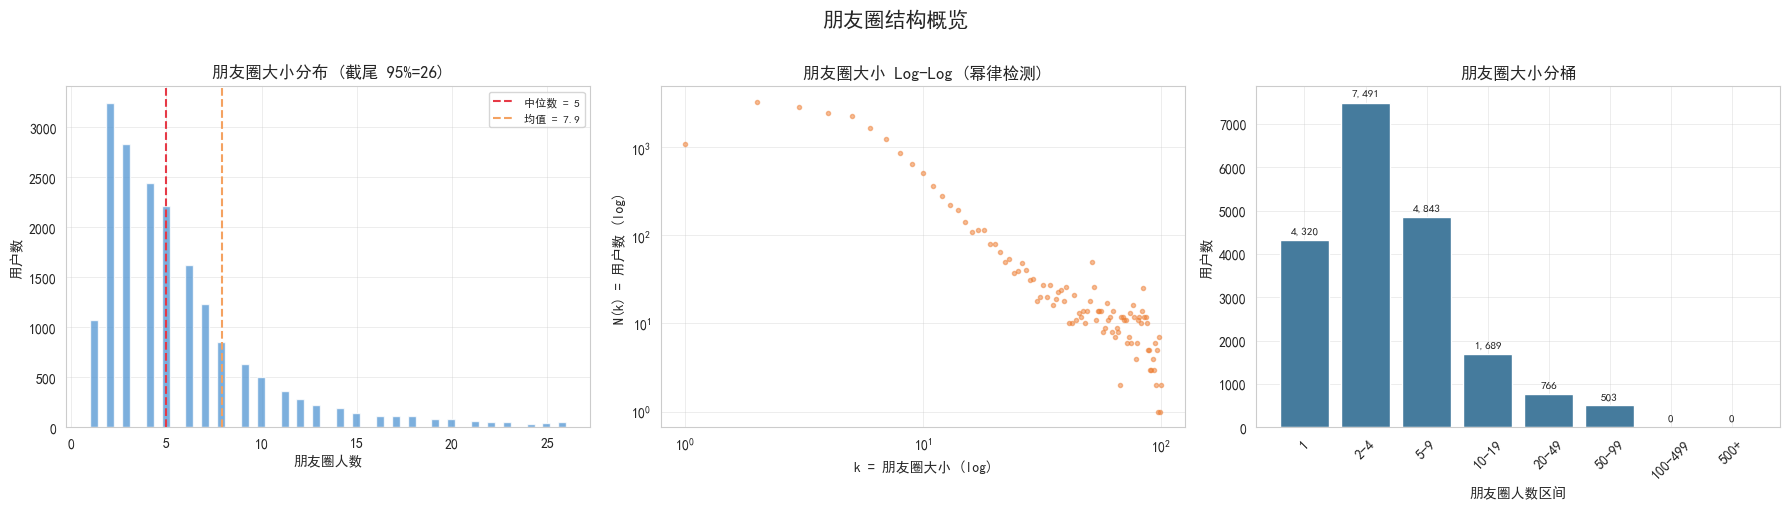


✅ Cell 1 完成


In [2]:
# ============================================================
# Cell 1 — 构建朋友圈字典
# friend_circle[inviter_id] = {voter_id_1, voter_id_2, ...}
# ============================================================
from collections import Counter

print("构建朋友圈...")

# 从训练数据聚合每个 inviter 分享过的所有 voter
friend_circle = df_train_all.groupby("inviter_id")["voter_id"].apply(set).to_dict()

# 同时构建反向索引
reverse_friend = df_train_all.groupby("voter_id")["inviter_id"].apply(set).to_dict()

print(f"朋友圈覆盖 inviter 数: {len(friend_circle):,}")
print(f"朋友圈平均大小:         {np.mean([len(s) for s in friend_circle.values()]):.1f}")
print(f"朋友圈中位数:           {np.median([len(s) for s in friend_circle.values()]):.0f}")
print(f"最大朋友圈:             {max(len(s) for s in friend_circle.values()):,}")

# ── 双向好友统计 ──
bidirectional_count = 0
total_friend_pairs = 0
for inviter, friends in friend_circle.items():
    for voter in friends:
        total_friend_pairs += 1
        if voter in friend_circle and inviter in friend_circle[voter]:
            bidirectional_count += 1

print(f"\n双向好友对数: {bidirectional_count:,} / {total_friend_pairs:,} "
      f"({bidirectional_count/total_friend_pairs*100:.1f}%)")

# ── 保存 ──
FRC_PATH = PROCESSED_DIR / "friend_circle.pkl"
with open(FRC_PATH, "wb") as f:
    pickle.dump({"friend_circle": friend_circle, "reverse_friend": reverse_friend}, f)
print(f"已保存至: {FRC_PATH}")

# ── 可视化 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
circle_sizes = [len(s) for s in friend_circle.values()]

# 子图1: 朋友圈大小分布（截尾 95%）
p95 = np.percentile(circle_sizes, 95)
axes[0].hist([s for s in circle_sizes if s <= p95], bins=60,
             color="#5B9BD5", edgecolor="white", alpha=0.8)
axes[0].axvline(np.median(circle_sizes), color="#E63946", linestyle="--", linewidth=1.5,
                label=f"中位数 = {np.median(circle_sizes):.0f}")
axes[0].axvline(np.mean(circle_sizes), color="#F4A261", linestyle="--", linewidth=1.5,
                label=f"均值 = {np.mean(circle_sizes):.1f}")
axes[0].set_title(f"朋友圈大小分布 (截尾 95%={p95:.0f})", fontsize=12, fontweight="bold")
axes[0].set_xlabel("朋友圈人数")
axes[0].set_ylabel("用户数")
axes[0].legend(fontsize=8)

# 子图2: Log-Log 幂律检测
size_counts = Counter(circle_sizes)
sizes_sorted = sorted(size_counts.keys())
counts_sorted = [size_counts[s] for s in sizes_sorted]
axes[1].loglog(sizes_sorted, counts_sorted, "o", markersize=3,
               color="#ED7D31", alpha=0.5)
axes[1].set_title("朋友圈大小 Log-Log (幂律检测)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("k = 朋友圈大小 (log)")
axes[1].set_ylabel("N(k) = 用户数 (log)")

# 子图3: 朋友圈大小分桶
bins = [0, 2, 5, 10, 20, 50, 100, 500, 10000]
labels = ["1", "2-4", "5-9", "10-19", "20-49", "50-99", "100-499", "500+"]
size_binned = pd.cut(circle_sizes, bins=bins, labels=labels)
bin_counts = size_binned.value_counts().sort_index()
axes[2].bar(range(len(bin_counts)), bin_counts.values, color="#457B9D", edgecolor="white")
axes[2].set_xticks(range(len(bin_counts)))
axes[2].set_xticklabels(bin_counts.index, rotation=45)
axes[2].set_title("朋友圈大小分桶", fontsize=12, fontweight="bold")
axes[2].set_xlabel("朋友圈人数区间")
axes[2].set_ylabel("用户数")
for i, v in enumerate(bin_counts.values):
    axes[2].text(i, v + max(bin_counts.values)*0.02, f"{v:,}", ha="center", fontsize=8)

fig.suptitle("朋友圈结构概览", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "13_friend_circle_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Cell 1 完成")

计算边级朋友圈特征...
边级特征: 155,716 条去重边

边级特征分布:
  share_count_a2b:   mean=4.63, median=1, max=1242
  响应率 = 0 (B 从未回流): 133,638 (85.8%)
  响应率 > 0 (B 有回流):   22,078 (14.2%)
  last_share_days:    mean=128, median=104

已保存至: D:\GNN\processed\edge_friend_features.pkl


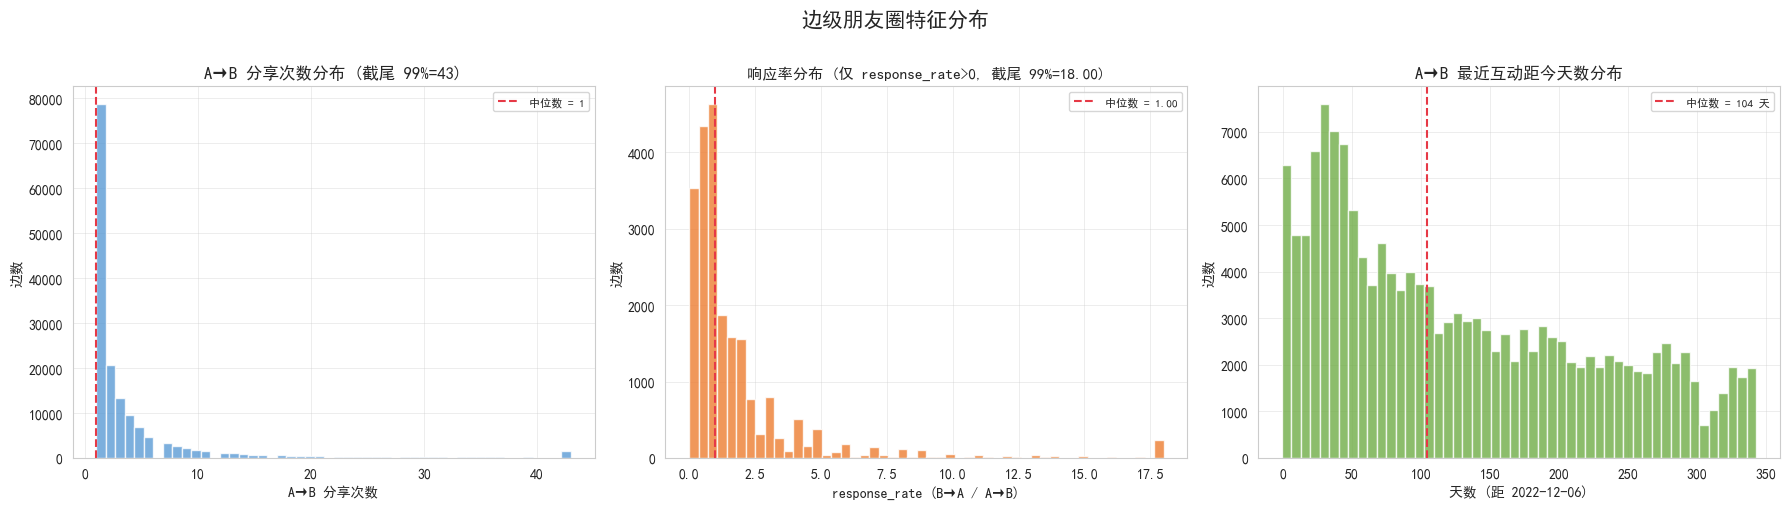


✅ Cell 2 完成


In [3]:
# ============================================================
# Cell 2 — 边级朋友圈特征
# ============================================================
print("计算边级朋友圈特征...")

# ── A→B 聚合 ──
a2b = df_train_all.groupby(["inviter_id", "voter_id"]).agg(
    share_count_a2b=("timestamp", "count"),
    last_share_a2b=("timestamp", "max"),
).reset_index()

# ── B→A 聚合 (回流) ──
b2a = df_train_all.groupby(["inviter_id", "voter_id"]).agg(
    share_count_b2a=("timestamp", "count"),
).reset_index()
b2a.columns = ["voter_id", "inviter_id", "share_count_b2a"]

# ── 合并 ──
edge_features = a2b.merge(b2a, on=["inviter_id", "voter_id"], how="left")
edge_features["share_count_b2a"] = edge_features["share_count_b2a"].fillna(0).astype(int)

# ── 计算衍生特征 ──
edge_features["is_friend"] = 1
edge_features["last_share_days"] = (
    REF_DATE - edge_features["last_share_a2b"]
).dt.days.fillna(-1).astype(int)
edge_features["response_rate"] = np.where(
    edge_features["share_count_a2b"] > 0,
    edge_features["share_count_b2a"] / edge_features["share_count_a2b"],
    0.0
)
edge_features["total_interactions"] = (
    edge_features["share_count_a2b"] + edge_features["share_count_b2a"]
)

# ── 精简列 ──
edge_features = edge_features[[
    "inviter_id", "voter_id",
    "is_friend", "share_count_a2b", "share_count_b2a",
    "total_interactions", "last_share_days", "response_rate"
]]

print(f"边级特征: {edge_features.shape[0]:,} 条去重边")

# ── 统计 ──
print(f"\n边级特征分布:")
print(f"  share_count_a2b:   mean={edge_features['share_count_a2b'].mean():.2f}, "
      f"median={edge_features['share_count_a2b'].median():.0f}, "
      f"max={edge_features['share_count_a2b'].max()}")
print(f"  响应率 = 0 (B 从未回流): {(edge_features['response_rate'] == 0).sum():,} "
      f"({(edge_features['response_rate'] == 0).mean()*100:.1f}%)")
print(f"  响应率 > 0 (B 有回流):   {(edge_features['response_rate'] > 0).sum():,} "
      f"({(edge_features['response_rate'] > 0).mean()*100:.1f}%)")
print(f"  last_share_days:    mean={edge_features['last_share_days'].mean():.0f}, "
      f"median={edge_features['last_share_days'].median():.0f}")

# ── 保存 ──
EDGE_PATH = PROCESSED_DIR / "edge_friend_features.pkl"
edge_features.to_pickle(EDGE_PATH)
print(f"\n已保存至: {EDGE_PATH}")

# ── 可视化 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1: share_count_a2b 分布（截尾 99%）
p99_a2b = edge_features["share_count_a2b"].quantile(0.99)
axes[0].hist(edge_features["share_count_a2b"].clip(upper=p99_a2b), bins=50,
             color="#5B9BD5", edgecolor="white", alpha=0.8)
axes[0].axvline(edge_features["share_count_a2b"].median(), color="#E63946",
                linestyle="--", linewidth=1.5,
                label=f"中位数 = {edge_features['share_count_a2b'].median():.0f}")
axes[0].set_title(f"A→B 分享次数分布 (截尾 99%={p99_a2b:.0f})", fontsize=12, fontweight="bold")
axes[0].set_xlabel("A→B 分享次数")
axes[0].set_ylabel("边数")
axes[0].legend(fontsize=8)

# 子图2: response_rate 分布（仅 response_rate > 0）
resp_pos = edge_features[edge_features["response_rate"] > 0]["response_rate"]
p99_resp = resp_pos.quantile(0.99)
axes[1].hist(resp_pos.clip(upper=p99_resp), bins=50,
             color="#ED7D31", edgecolor="white", alpha=0.8)
axes[1].axvline(resp_pos.median(), color="#E63946", linestyle="--", linewidth=1.5,
                label=f"中位数 = {resp_pos.median():.2f}")
axes[1].set_title(f"响应率分布 (仅 response_rate>0, 截尾 99%={p99_resp:.2f})",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("response_rate (B→A / A→B)")
axes[1].set_ylabel("边数")
axes[1].legend(fontsize=8)

# 子图3: last_share_days 分布
axes[2].hist(edge_features["last_share_days"], bins=50,
             color="#70AD47", edgecolor="white", alpha=0.8)
axes[2].axvline(edge_features["last_share_days"].median(), color="#E63946",
                linestyle="--", linewidth=1.5,
                label=f"中位数 = {edge_features['last_share_days'].median():.0f} 天")
axes[2].set_title("A→B 最近互动距今天数分布", fontsize=12, fontweight="bold")
axes[2].set_xlabel("天数 (距 2022-12-06)")
axes[2].set_ylabel("边数")
axes[2].legend(fontsize=8)

fig.suptitle("边级朋友圈特征分布", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_edge_friend_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Cell 2 完成")

═══════════════════════════════════════════════════════
  预分析 — 朋友圈加权策略的实证依据
═══════════════════════════════════════════════════════

按 A→B 分享次数分层:
interaction_bin    边数    平均响应率      双向率
             1次 78774 0.240866 0.043910
             2次 20604 0.351073 0.132887
             3次 13267 0.311751 0.170423
           4-5次 16328 0.359588 0.252695
          6-10次 14295 0.326723 0.308010
            10+ 12072 0.341533 0.411448

按 A→B 最近互动距今天数分层:
recency_bin    边数    平均响应率      双向率
        ≤7天  7575 0.419488 0.351551
      8-30天 18517 0.596406 0.344332
     31-90天 44243 0.353581 0.179961
    91-180天 38497 0.189945 0.075590
      180天+ 46665 0.166240 0.044487

双向 vs 单向对比:
is_bidirectional     边数   平均交互次数     平均最近天数
         单向(无回流) 133638 3.930087 138.193553
         双向(有回流)  22078 8.872815  63.152958


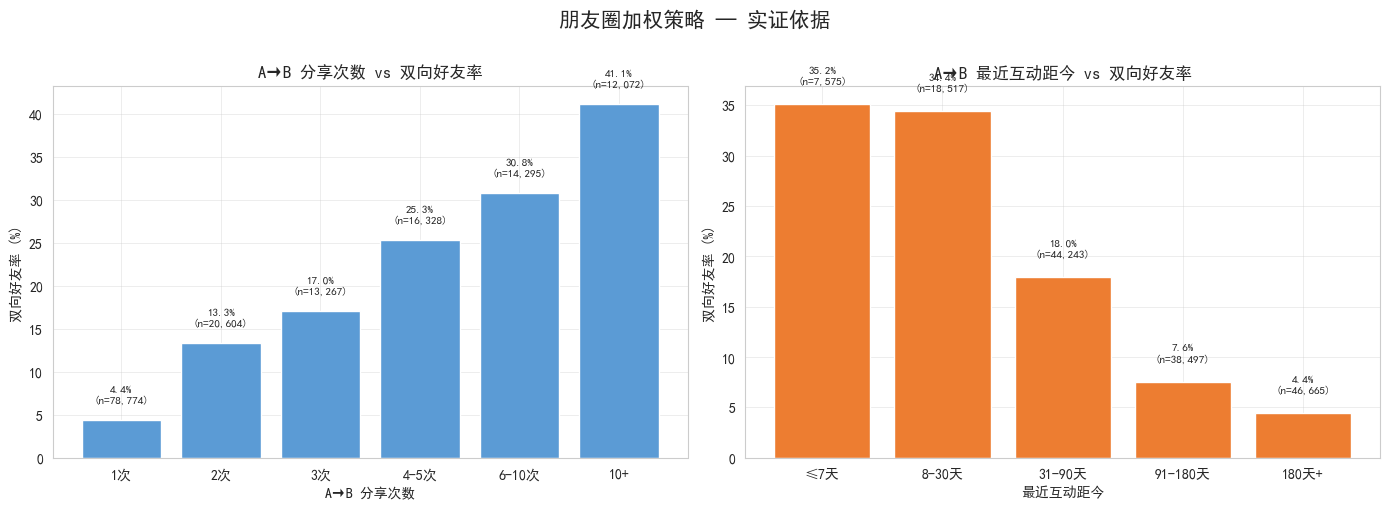


─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
结论:
  如果 A→B 分享次数越多、最近互动越近，B 的响应率越高 →
  则朋友圈加权策略有实证支撑，可直接写入 AB 测试实验设计书。
═══════════════════════════════════════════════════════


In [4]:
# ============================================================
# Cell 3 — 预分析：朋友圈加权策略的数据支撑
# ============================================================
print("═" * 55)
print("  预分析 — 朋友圈加权策略的实证依据")
print("═" * 55)

# ── 按交互强度分层看响应率 ──
edge_features["interaction_bin"] = pd.cut(
    edge_features["share_count_a2b"],
    bins=[0, 1, 2, 3, 5, 10, 100],
    labels=["1次", "2次", "3次", "4-5次", "6-10次", "10+"]
)

grouped = edge_features.groupby("interaction_bin", observed=True).agg(
    边数=("response_rate", "count"),
    平均响应率=("response_rate", "mean"),
    双向率=("response_rate", lambda x: (x > 0).mean()),
).reset_index()

print("\n按 A→B 分享次数分层:")
print(grouped.to_string(index=False))

# ── 按 last_share_days 分层看响应率 ──
edge_features["recency_bin"] = pd.cut(
    edge_features["last_share_days"],
    bins=[-1, 7, 30, 90, 180, 365],
    labels=["≤7天", "8-30天", "31-90天", "91-180天", "180天+"]
)

recency_grouped = edge_features.groupby("recency_bin", observed=True).agg(
    边数=("response_rate", "count"),
    平均响应率=("response_rate", "mean"),
    双向率=("response_rate", lambda x: (x > 0).mean()),
).reset_index()

print("\n按 A→B 最近互动距今天数分层:")
print(recency_grouped.to_string(index=False))

# ── 按双向/单向分组 ──
edge_features["is_bidirectional"] = edge_features["response_rate"] > 0
bi_stats = edge_features.groupby("is_bidirectional").agg(
    边数=("response_rate", "count"),
    平均交互次数=("share_count_a2b", "mean"),
    平均最近天数=("last_share_days", "mean"),
).reset_index()
bi_stats["is_bidirectional"] = bi_stats["is_bidirectional"].map({True: "双向(有回流)", False: "单向(无回流)"})
print("\n双向 vs 单向对比:")
print(bi_stats.to_string(index=False))

# ── 可视化 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x1 = np.arange(len(grouped))
axes[0].bar(x1, grouped["双向率"] * 100, color="#5B9BD5", edgecolor="white")
axes[0].set_xticks(x1)
axes[0].set_xticklabels(grouped["interaction_bin"])
axes[0].set_title("A→B 分享次数 vs 双向好友率", fontsize=12, fontweight="bold")
axes[0].set_xlabel("A→B 分享次数")
axes[0].set_ylabel("双向好友率 (%)")
for i, (v, n) in enumerate(zip(grouped["双向率"] * 100, grouped["边数"])):
    axes[0].text(i, v + 2, f"{v:.1f}%\n(n={n:,})", ha="center", fontsize=8)

x2 = np.arange(len(recency_grouped))
axes[1].bar(x2, recency_grouped["双向率"] * 100, color="#ED7D31", edgecolor="white")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(recency_grouped["recency_bin"])
axes[1].set_title("A→B 最近互动距今 vs 双向好友率", fontsize=12, fontweight="bold")
axes[1].set_xlabel("最近互动距今")
axes[1].set_ylabel("双向好友率 (%)")
for i, (v, n) in enumerate(zip(recency_grouped["双向率"] * 100, recency_grouped["边数"])):
    axes[1].text(i, v + 2, f"{v:.1f}%\n(n={n:,})", ha="center", fontsize=8)

fig.suptitle("朋友圈加权策略 — 实证依据", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "15_friend_weight_evidence.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n─" * 40)
print("结论:")
print("  如果 A→B 分享次数越多、最近互动越近，B 的响应率越高 →")
print("  则朋友圈加权策略有实证支撑，可直接写入 AB 测试实验设计书。")
print("═" * 55)

---\n## 双向好友率分析\n\n每个用户的朋友圈中，有多少比例的朋友也反过来分享给该用户？\n- **双向率 = 0** → 完全单向传播者（只分享给别人，别人不回）\n- **双向率 = 1** → 完全双向互动（每个朋友都互相分享）\n- 这个指标反映用户在社交网络中的关系质量

计算每个用户的双向好友率...


双向率: 100%|██████████| 19612/19612 [00:00<00:00, 189719.31it/s]

双向好友率: mean=0.110, median=0.000
  完全单向 (率=0):       14,447 (73.7%)
  低双向   (0 < 率 ≤ 0.3): 2,412
  中双向   (0.3< 率 ≤ 0.7): 1,667
  高双向   (率 > 0.7):    1,086
  完全双向 (率=1):       559 (2.9%)


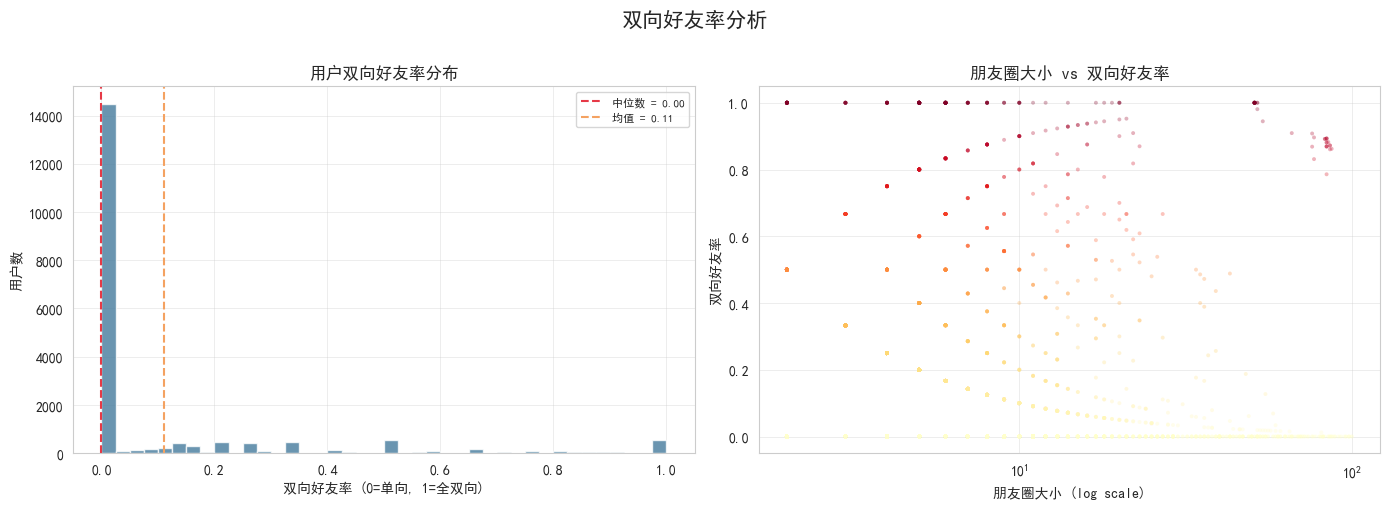


✅ Cell 4 完成


In [5]:
# ============================================================
# Cell 4 — 每个用户的双向好友率统计
# ============================================================
print("计算每个用户的双向好友率...")

user_bi_ratios = {}
for user_id, friends in tqdm(friend_circle.items(), total=len(friend_circle), desc="双向率"):
    if len(friends) == 0:
        user_bi_ratios[user_id] = 0.0
        continue
    bi_count = sum(1 for f_id in friends
                   if f_id in friend_circle and user_id in friend_circle.get(f_id, set()))
    user_bi_ratios[user_id] = bi_count / len(friends)

bi_ratios = list(user_bi_ratios.values())
print(f"双向好友率: mean={np.mean(bi_ratios):.3f}, median={np.median(bi_ratios):.3f}")
print(f"  完全单向 (率=0):       {sum(1 for r in bi_ratios if r == 0):,} "
      f"({sum(1 for r in bi_ratios if r == 0)/len(bi_ratios)*100:.1f}%)")
print(f"  低双向   (0 < 率 ≤ 0.3): {sum(1 for r in bi_ratios if 0 < r <= 0.3):,}")
print(f"  中双向   (0.3< 率 ≤ 0.7): {sum(1 for r in bi_ratios if 0.3 < r <= 0.7):,}")
print(f"  高双向   (率 > 0.7):    {sum(1 for r in bi_ratios if r > 0.7):,}")
print(f"  完全双向 (率=1):       {sum(1 for r in bi_ratios if r == 1):,} "
      f"({sum(1 for r in bi_ratios if r == 1)/len(bi_ratios)*100:.1f}%)")

# ── 可视化 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(bi_ratios, bins=40, color="#457B9D", edgecolor="white", alpha=0.8)
axes[0].axvline(np.median(bi_ratios), color="#E63946", linestyle="--", linewidth=1.5,
                label=f"中位数 = {np.median(bi_ratios):.2f}")
axes[0].axvline(np.mean(bi_ratios), color="#F4A261", linestyle="--", linewidth=1.5,
                label=f"均值 = {np.mean(bi_ratios):.2f}")
axes[0].set_title("用户双向好友率分布", fontsize=12, fontweight="bold")
axes[0].set_xlabel("双向好友率 (0=单向, 1=全双向)")
axes[0].set_ylabel("用户数")
axes[0].legend(fontsize=8)

# 子图2: 朋友圈大小 vs 双向好友率 (采样 30%)
circle_sizes_arr = np.array([len(friend_circle.get(uid, set())) for uid in user_bi_ratios.keys()])
bi_ratios_arr = np.array(bi_ratios)
mask = (circle_sizes_arr >= 2) & (np.random.random(len(circle_sizes_arr)) < 0.3)
axes[1].scatter(circle_sizes_arr[mask], bi_ratios_arr[mask],
                c=bi_ratios_arr[mask], cmap="YlOrRd", alpha=0.3, s=8, edgecolors="none")
axes[1].set_xscale("log")
axes[1].set_xlabel("朋友圈大小 (log scale)")
axes[1].set_ylabel("双向好友率")
axes[1].set_title("朋友圈大小 vs 双向好友率", fontsize=12, fontweight="bold")

fig.suptitle("双向好友率分析", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "16_bidirectional_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Cell 4 完成")

In [6]:
# ============================================================
# Cell 6 — 收尾：确认产物文件都已生成
# ============================================================
print("产物文件清单:")
for pkl_file in ["friend_circle.pkl", "edge_friend_features.pkl"]:
    path = PROCESSED_DIR / pkl_file
    exists = "✅" if path.exists() else "❌"
    size_mb = path.stat().st_size / 1024**2 if path.exists() else 0
    print(f"  {exists} {pkl_file:30s} ({size_mb:.1f} MB)")

print("\n🎉 1.3 朋友圈构建 + 边级特征 + 交互可视化 — 完成")

产物文件清单:
  ✅ friend_circle.pkl              (11.4 MB)
  ✅ edge_friend_features.pkl       (12.0 MB)

🎉 1.3 朋友圈构建 + 边级特征 + 交互可视化 — 完成
